In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
!pip install xlrd

In [4]:
df = pd.read_excel("Concrete_Data.xls")

In [5]:
len(df)

1030

In [6]:
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [7]:
df.columns = ["Cement", "BlastFurnaceSlag", "FlyAsh", "Water", "Superplasticizer", 
              "CoarseAggregate", "FineAggregate", "Age", "CompressiveStrength"]

In [8]:
df.describe()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,CompressiveStrength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [9]:
df.isna().sum()

Cement                 0
BlastFurnaceSlag       0
FlyAsh                 0
Water                  0
Superplasticizer       0
CoarseAggregate        0
FineAggregate          0
Age                    0
CompressiveStrength    0
dtype: int64

<Axes: >

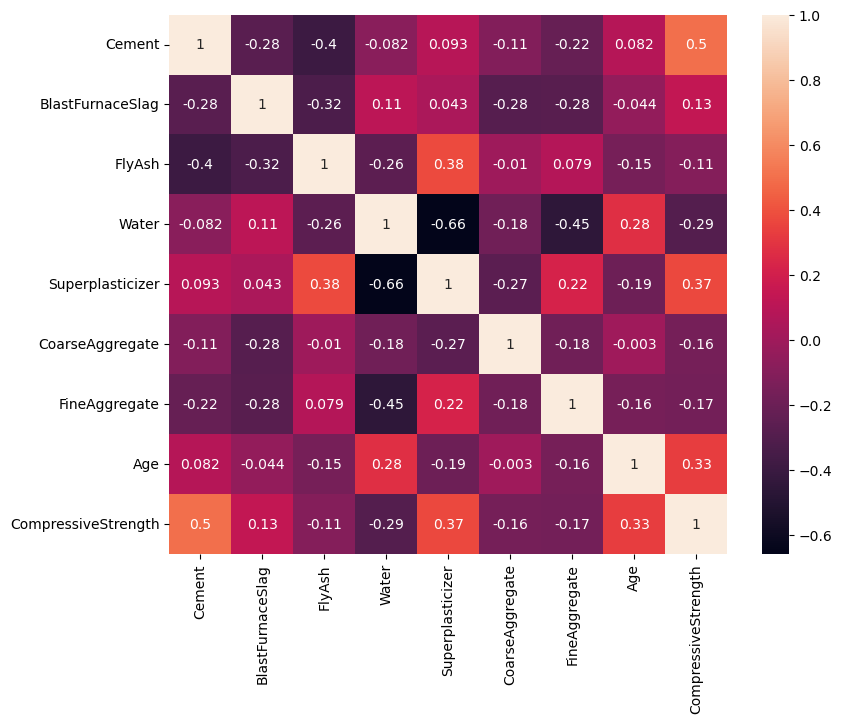

In [10]:
plt.figure(figsize=(9,7))
sns.heatmap(df.corr(), annot=True)

C:\Users\ANJALI\AppData\Local\Temp\ipykernel_50820\1173490987.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(df.CompressiveStrength)


Text(0.5, 1.0, 'Compressive Strength Distribution')

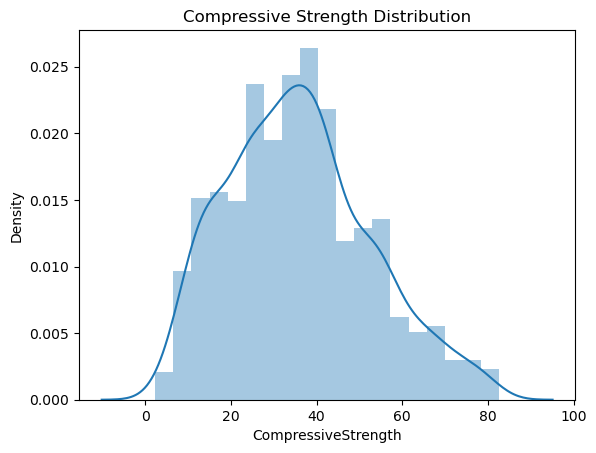

In [11]:
ax = sns.distplot(df.CompressiveStrength)
ax.set_title("Compressive Strength Distribution")

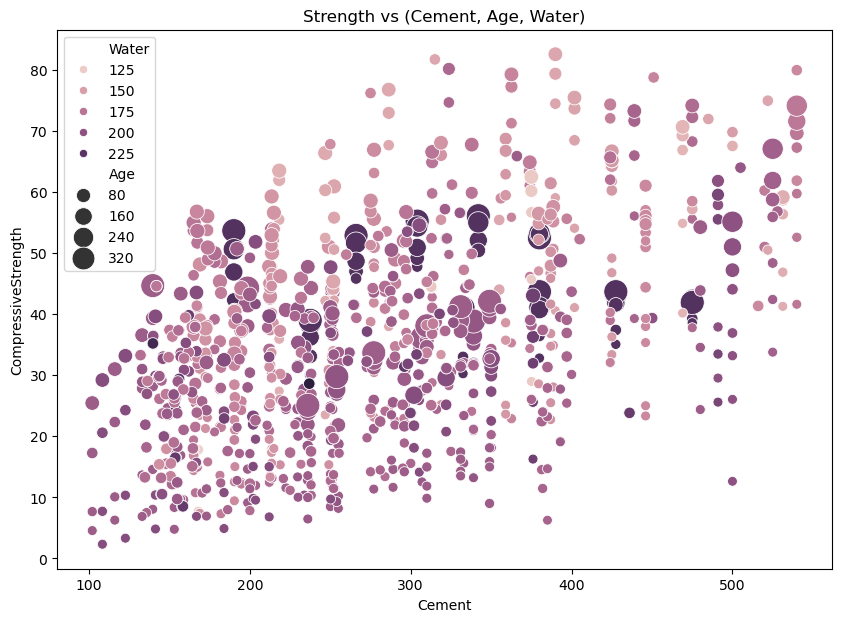

In [12]:
fig, ax = plt.subplots(figsize=(10,7))
sns.scatterplot(y="CompressiveStrength", x="Cement", hue="Water", size="Age", data=df, ax=ax, sizes=(50, 300))
ax.set_title("Strength vs (Cement, Age, Water)")
plt.show()

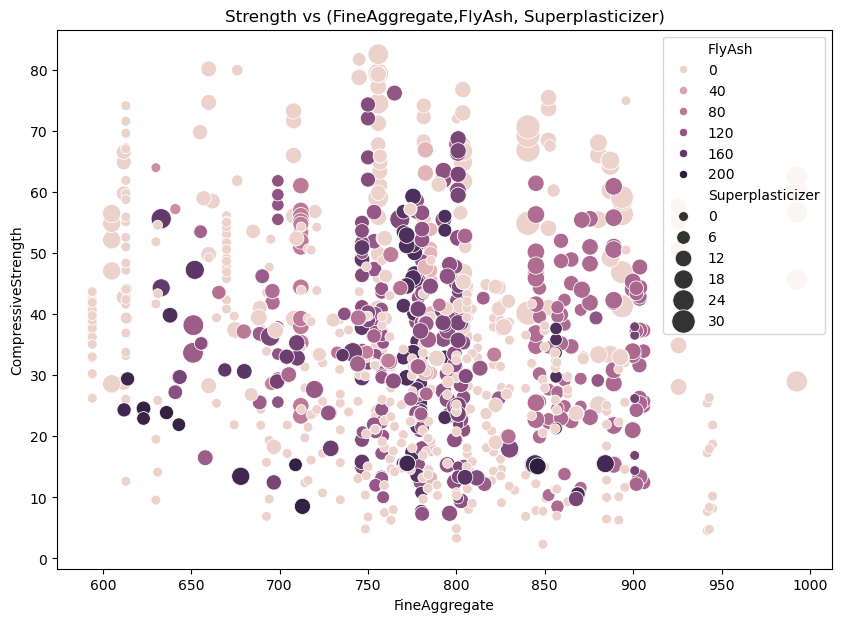

In [13]:
fig, ax = plt.subplots(figsize=(10,7))
sns.scatterplot(y="CompressiveStrength", x="FineAggregate", hue="FlyAsh", size="Superplasticizer", data=df, ax=ax, sizes=(50, 300))
ax.set_title("Strength vs (FineAggregate,FlyAsh, Superplasticizer)")
plt.show()

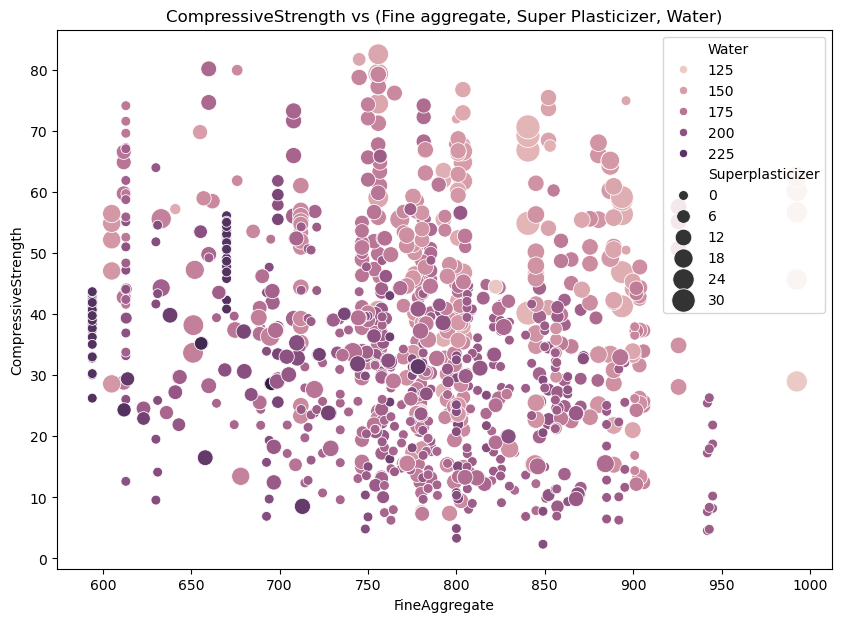

In [14]:
fig, ax = plt.subplots(figsize=(10,7))
sns.scatterplot(y="CompressiveStrength", x="FineAggregate", hue="Water", size="Superplasticizer", 
                data=df, ax=ax, sizes=(50, 300))
ax.set_title("CompressiveStrength vs (Fine aggregate, Super Plasticizer, Water)")
plt.show()

In [15]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [18]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [19]:
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [20]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge

In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [22]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [23]:
dtr = DecisionTreeRegressor()
rfr = RandomForestRegressor(n_estimators=50)
lr = LinearRegression()
lasso = Lasso()
ridge = Ridge()

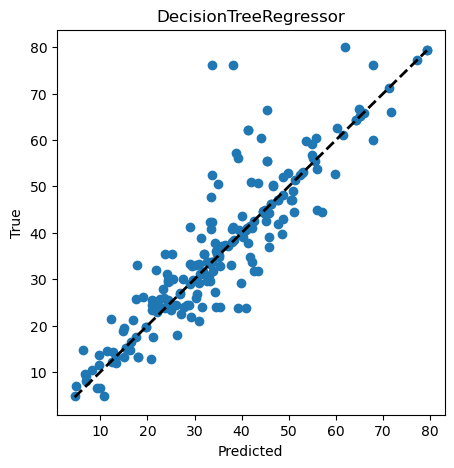

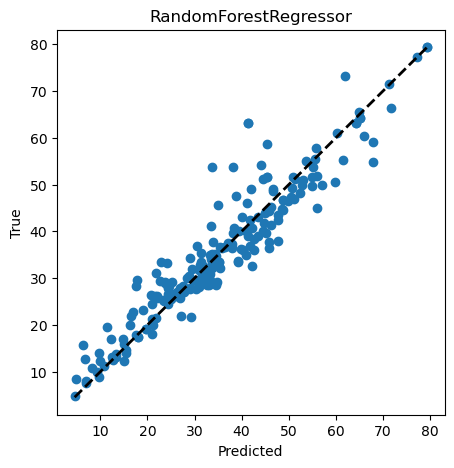

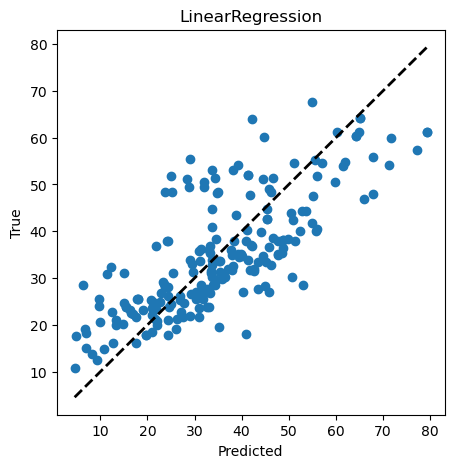

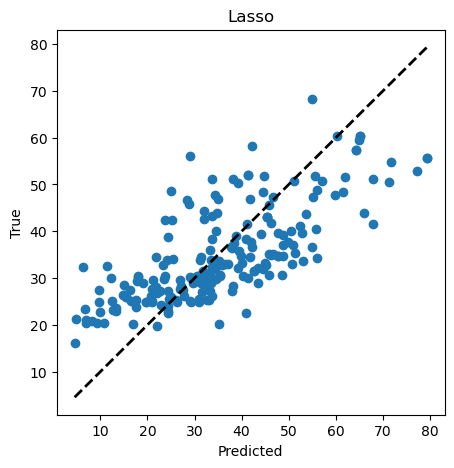

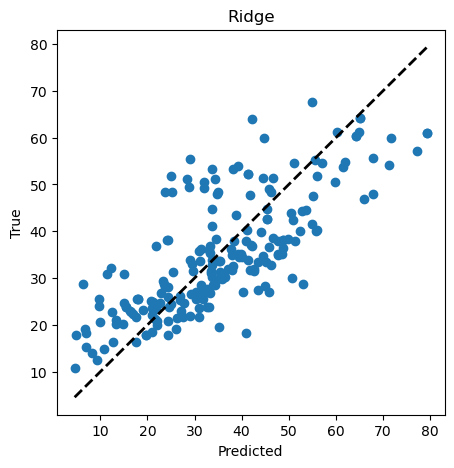

In [24]:
results=[]
clfs =[dtr, rfr, lr, lasso, ridge ]
for clf in clfs:
    clf.fit(X_train, y_train) 
    y_pred = clf.predict(X_test)
   
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append([clf.__class__.__name__, rmse, mse, mae, r2])

    plt.figure(figsize=(5, 5))
    plt.scatter(y_test, y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(clf.__class__.__name__)
    plt.show()

In [25]:
df_compare = pd.DataFrame(results, columns=['classifier', 'RMSE', 'MSE', 'MAE', 'R2_score'] )
print(df_compare)

              classifier       RMSE         MSE       MAE  R2_score
0  DecisionTreeRegressor   7.503072   56.296086  4.590223  0.771171
1  RandomForestRegressor   5.194432   26.982125  3.585792  0.890325
2       LinearRegression  10.285045  105.782157  8.227065  0.570023
3                  Lasso  10.683378  114.134566  8.655700  0.536072
4                  Ridge  10.288679  105.856919  8.235756  0.569719


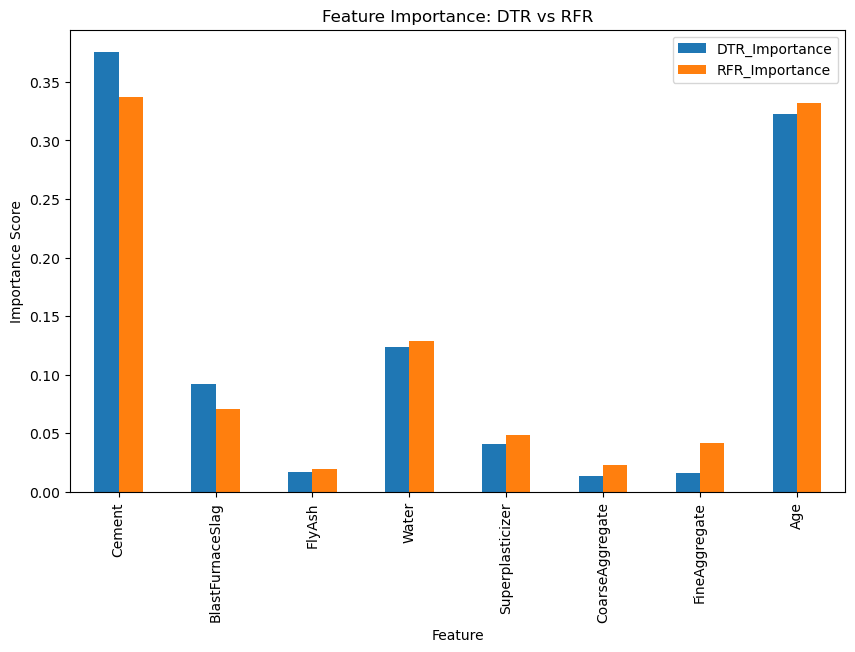

In [26]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'DTR_Importance': dtr.feature_importances_,
    'RFR_Importance': rfr.feature_importances_
})

importance_df.set_index('Feature').plot(kind='bar', figsize=(10, 6))
plt.title('Feature Importance: DTR vs RFR')
plt.ylabel('Importance Score')
plt.show()

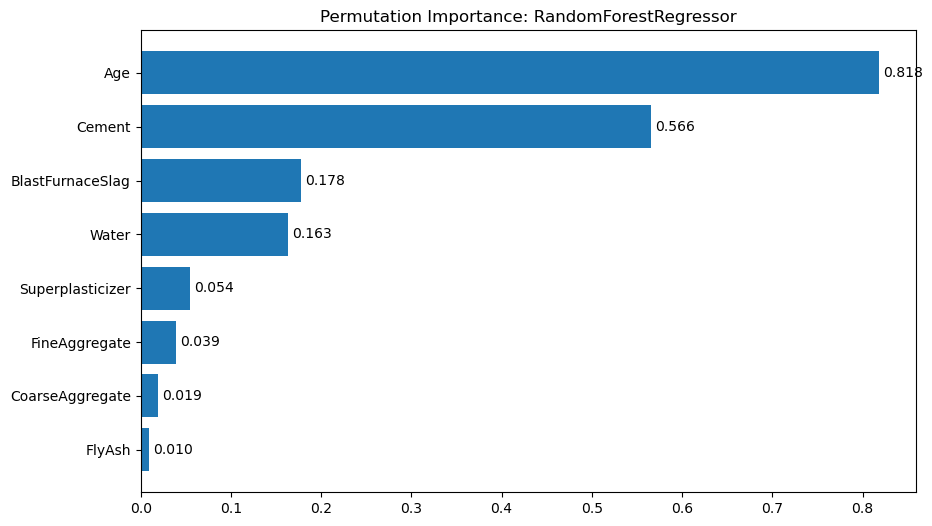

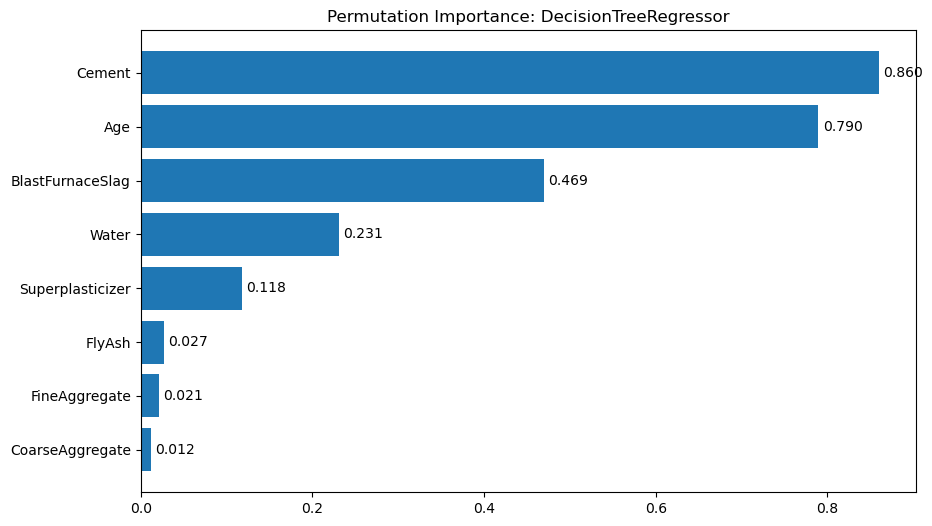

In [27]:
from sklearn.inspection import permutation_importance

clfs2=[rfr, dtr]

for clf in clfs2:
    perm_importance = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42)
    
    sorted_idx = perm_importance.importances_mean.argsort()
    fig, ax = plt.subplots(figsize=(10, 6)) 
    
    bars = ax.barh(range(X.shape[1]), perm_importance.importances_mean[sorted_idx])
    
    ax.bar_label(bars, fmt='%.3f', padding=3)
    
    ax.set_yticks(range(X.shape[1]))
    ax.set_yticklabels(X.columns[sorted_idx])
    ax.set_title(f"Permutation Importance: {clf.__class__.__name__}")
    plt.show()

In [28]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_grid = {
    'n_estimators': [150, 200, 250],
    'max_depth': [None, 2, 4],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=rf_param_grid,
    n_iter=50,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_train, y_train)
print("Best RFR params:", rf_search.best_params_)
print("Best CV RMSE:", -rf_search.best_score_)

best_rfr = rf_search.best_estimator_
y_pred_tuned_rfr = best_rfr.predict(X_test)
print("Tuned RFR Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tuned_rfr)))
print("Tuned RFR Test R2:", r2_score(y_test, y_pred_tuned_rfr))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best RFR params: {'n_estimators': 150, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best CV RMSE: 5.249788467974247
Tuned RFR Test RMSE: 4.980664279037592
Tuned RFR Test R2: 0.8991658284467837


In [29]:
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

dt_search = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_distributions=dt_param_grid,
    n_iter=50,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

dt_search.fit(X_train, y_train)
print("Best DTR params:", dt_search.best_params_)
print("Best CV RMSE:", -dt_search.best_score_)

best_dtr = dt_search.best_estimator_
y_pred_tuned_dtr = best_dtr.predict(X_test)
print("Tuned DTR Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tuned_dtr)))
print("Tuned DTR Test R2:", r2_score(y_test, y_pred_tuned_dtr))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best DTR params: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 15}
Best CV RMSE: 6.778238849387091
Tuned DTR Test RMSE: 7.303916120123177
Tuned DTR Test R2: 0.7831573279641343


In [30]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

default_gbr = GradientBoostingRegressor(random_state=42)

rfr_scores = cross_val_score( best_rfr, X_train, y_train, cv=cv_strategy, scoring="r2")
rfr_mean = rfr_scores.mean()
rfr_std = rfr_scores.std()

dtr_scores = cross_val_score(
    best_dtr, X_train, y_train, cv=cv_strategy, scoring="r2"
)
dtr_mean = dtr_scores.mean()
dtr_std = dtr_scores.std()

gbr_scores = cross_val_score(
    default_gbr, X_train, y_train, cv=cv_strategy, scoring="r2"
)
gbr_mean = gbr_scores.mean()
gbr_std = gbr_scores.std()


final_data = [
    ["Tuned RFR", rfr_mean, rfr_std],
    ["Tuned DTR", dtr_mean, dtr_std],
    ["GradientBoosting (default)", gbr_mean, gbr_std],
]

cv_results_df = pd.DataFrame(final_data, columns=['Model', 'Mean_R2', 'Std_R2'])
cv_results_df

,Model,Mean_R2,Std_R2
0,Tuned RFR,0.903398,0.017124
1,Tuned DTR,0.823647,0.022267
2,GradientBoosting (default),0.906237,0.015577


In [31]:
import pickle
pickle.dump(default_gbr, open('model.pkl', 'wb'))